# Model-based Reinforcement Learning

In Dynamic Programming (Chapter 03) the algorithms **require a model** of the environment, the dynamics function $\displaystyle p(s', r \mid s, a)$, and compute optimal policies offline, without ever interacting with the environment. In Chapter 05 we went to the opposite extreme: the **model-free** methods (Monte Carlo, TD, SARSA, Q-learning) learn values and policies directly from experience and require no information about the MDP internals. The advantage is clear: often the MDP is very hard to obtain in advance, or simply impossible to write down. Think of the game of Go, with about $\displaystyle 10^{170}$ legal positions, or of StarCraft II, whose state space has been estimated at around $\displaystyle 10^{1685}$ states: nobody can hand the agent a transition table of that size. Not requiring the MDP in advance is therefore of crucial importance.

However, there is a middle way. What if we do not *require* the model in advance, but **learn one as we interact** with the environment? An agent can interact with the environment (as model-free methods do), use each experience tuple to update a *model* of the environment, and then use the learned model to improve its behaviour with computations that resemble Dynamic Programming. We call this second phase **planning**, because it is based on the model and not on new interaction. By exploiting the learned model, agents extract more information from every real experience sample, and often need fewer of them to learn a good policy. These methods are called **model-based reinforcement learning**.

We use again the **Slippery Walk** environment of Chapter 05: a single-row slippery (stochastic) grid world with seven non-terminal states. If the agent chooses to go left, with probability $1/2$ it does, but with probability $1/3$ it stays in place and with probability $1/6$ it goes right instead (and symmetrically for the action right). Reaching the rightmost terminal state gives reward $+1$, every other transition gives $0$:

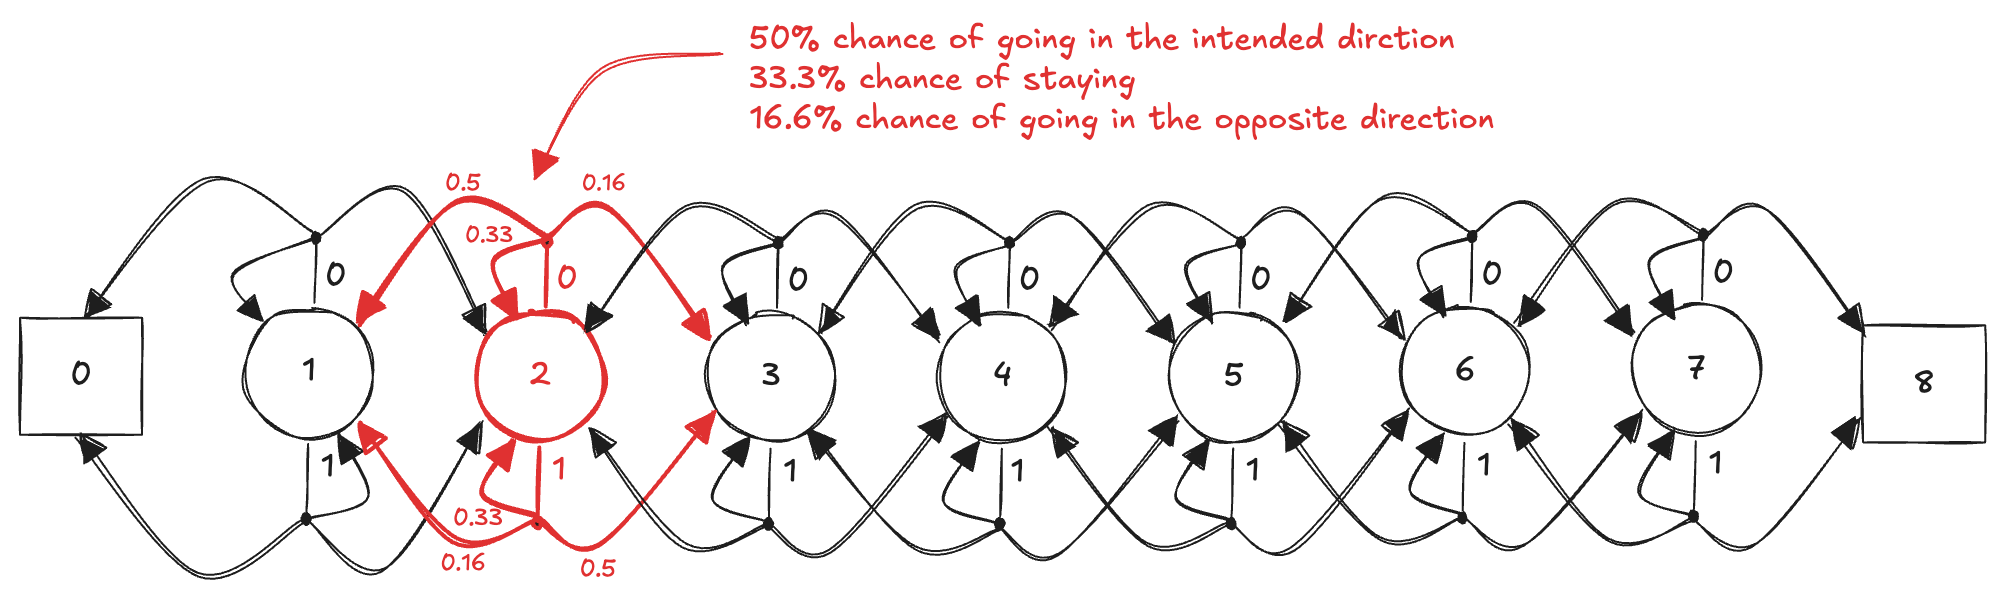

In [1]:
import random
import numpy as np

class SlipperyWalk:
    def __init__(self):
        self.reset();

    def reset(self):
        self.observation_space = 9;
        self.action_space = 2;
        self.state = np.random.choice([1,2,3,4,5,6,7]);
        self.terminated = False;
        return self.state;

    def step(self, action):
        if self.terminated: raise ValueError('Episode has terminated');
        if action not in [0, 1]: raise ValueError('Invalid action');

        if(action==0): direction = -1;
        if(action==1): direction = 1;

        # intended direction with probability 1/2, opposite with 1/6, stay with 1/3
        direction_list = [direction, -direction, 0];
        true_direction = random.choices(direction_list, weights=(3, 1, 2), k=1);
        self.state += true_direction[0];

        reward = 0
        if self.state < 1: self.terminated = True;
        if self.state > 7: self.terminated = True; reward = 1;
        return self.state, reward, self.terminated, 0, 0;

In [2]:
slippery_walk = SlipperyWalk();

# optimal state-value function, computed with value iteration (Chapter 03) on the true MDP
optimal_v = [0., 0.5637, 0.763, 0.8449, 0.8892, 0.922, 0.9515, 0.9806, 0.];

## What is a model, and how do we learn one?

Before learning a model we must be precise about what a model is. In Chapter 02 we defined the **dynamics function** of an MDP as the joint probability of next state and reward given the current state and action, $\displaystyle p(s', r \mid s, a)$, and we derived from it the **transition function** $\displaystyle p(s' \mid s, a) = \sum_r p(s', r \mid s, a)$ and the **expected reward of a transition** $\displaystyle r(s, a, s') = \mathbb{E}[R_{t+1} \mid S_t = s, A_t = a, S_{t+1} = s']$. A **model** of the environment is anything the agent can use to predict how the environment will respond to its actions; in the tabular setting it is exactly an estimate of these two functions. Sutton & Barto distinguish two kinds of model. A **distribution model** returns all the possible next states together with their probabilities: this is what Dynamic Programming needs, and what the dictionary `env.unwrapped.P` provided in Chapters 02–03. A **sample model** only needs to return *one* next state and reward, drawn with the right probabilities, exactly like a call to `env.step()`. A distribution model can always be used as a sample model (just sample from it), while the converse is not true; but sample models are much easier to obtain and, as we will see, they are all that the algorithms of this chapter need.

**Learning the model by counting.** Since the environment is a finite MDP, the most natural estimate of the transition function is the relative frequency of the observed transitions. Let $\displaystyle N(s,a,s')$ be the number of times the agent, being in $s$ and selecting $a$, landed in $s'$, and let $\displaystyle N(s,a) = \sum_{s'} N(s,a,s')$ be the number of times the pair $(s,a)$ has been tried. The estimated transition function is

$\displaystyle \hat p(s' \mid s, a) = \frac{N(s,a,s')}{N(s,a)}$

This is not just a reasonable guess: it is the **maximum-likelihood estimate**. Fix a pair $(s,a)$ and call $\displaystyle \theta_{s'} = p(s' \mid s, a)$ the unknown probabilities. The observed next states are independent draws from this distribution, so the log-likelihood of the data is

$\displaystyle \log \mathcal{L}(\theta) = \sum_{s'} N(s,a,s') \log \theta_{s'}, \qquad \text{subject to} \quad \sum_{s'} \theta_{s'} = 1$

Maximising with a Lagrange multiplier $\lambda$ for the constraint, the stationarity condition for each $\theta_{s'}$ is

$\displaystyle \frac{\partial}{\partial \theta_{s'}} \Big[ \sum_{s''} N(s,a,s'') \log \theta_{s''} - \lambda \Big( \sum_{s''} \theta_{s''} - 1 \Big) \Big] = \frac{N(s,a,s')}{\theta_{s'}} - \lambda = 0 \quad \Longrightarrow \quad \theta_{s'} = \frac{N(s,a,s')}{\lambda}$

and summing over $s'$ the constraint gives $\displaystyle \lambda = \sum_{s'} N(s,a,s') = N(s,a)$, which is the frequency estimate above.

For the reward we keep a running estimate of the expected reward of each transition, $\displaystyle \hat r(s,a,s') \approx r(s,a,s')$, updated as an **incremental mean**: the same pattern we met with the bandits of Chapter 04, $\text{NewEstimate} \leftarrow \text{OldEstimate} + \text{StepSize} \times (\text{Target} - \text{OldEstimate})$ with step size $1/n$. After observing the transition $(s, a, R_{t+1}, s')$ and having incremented the count,

$\displaystyle \hat r(s,a,s') \leftarrow \hat r(s,a,s') + \frac{1}{N(s,a,s')} \big[ R_{t+1} - \hat r(s,a,s') \big]$

If needed, the expected reward of a pair follows by marginalisation, exactly as in Chapter 02: $\displaystyle \hat r(s,a) = \sum_{s'} \hat p(s' \mid s, a)\, \hat r(s,a,s')$. In the environments of this course the reward is a deterministic function of the transition, so $\hat r(s,a,s')$ is exact after a single observation; the incremental mean makes the code correct also for stochastic rewards.

In code we store $N$ and $\hat r$ as two three-dimensional arrays indexed by (state, action, next state): `transitions[s][a]` is a row of counts whose normalisation is the row $\hat p(\cdot \mid s, a)$, and `rewards[s][a][s_next]` is $\hat r(s,a,s')$.

**Limitations of the counting model.** Two things should be clear before we use it. First, $\hat p(\cdot \mid s,a)$ is *undefined* for pairs that have never been tried ($N(s,a) = 0$): the model knows nothing about them, and any planning algorithm must restrict itself to visited pairs. Second, early in learning the counts are small and the estimates are noisy: planning with a wrong model propagates the error of the model into the value function. Both issues will show up in the experiments below. Finally, a table of counts is possible only when states and actions are discrete and not too many; with large or continuous state spaces the model must become a parametric function (typically a neural network), a topic we leave to the deep RL chapters.

## Planning with a learned model

**Planning**, in the sense used in this chapter, is any computation that takes a model as input and produces or improves a policy *without* new interaction with the environment. Dynamic Programming is planning with the true model; here we plan with the learned one, treating $\hat p$ and $\hat r$ *as if* they were the truth. There are two ways to use the model to update the action-value estimate of a pair $(s,a)$.

The first is an **expected (full) backup**: the Bellman optimality update of value iteration (Chapter 03), with the true dynamics replaced by the estimated ones,

$\displaystyle Q(s,a) \leftarrow \sum_{s'} \hat p(s' \mid s, a) \Big[ \hat r(s,a,s') + \gamma \max_{a'} Q(s',a') \Big]$

It requires a distribution model and costs one term per possible successor, $O(|\mathcal{S}|)$ per update in the worst case.

The second is a **sample backup**: we draw one next state from the model, $\displaystyle s' \sim \hat p(\cdot \mid s, a)$, read the reward $\displaystyle r = \hat r(s,a,s')$, and treat the *simulated* tuple $(s, a, r, s')$ exactly like a real one, applying the Q-learning update of Chapter 05:

$\displaystyle Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \Big]$

It only needs a sample model and costs $O(1)$ per update, at the price of variance: the sampled target $\displaystyle r + \gamma \max_{a'} Q(s',a')$ is a random variable, but its expectation over $s' \sim \hat p(\cdot \mid s,a)$ is precisely the bracket of the expected backup,

$\displaystyle \mathbb{E}_{s' \sim \hat p(\cdot \mid s,a)} \Big[ \hat r(s,a,s') + \gamma \max_{a'} Q(s',a') \Big] = \sum_{s'} \hat p(s' \mid s, a) \Big[ \hat r(s,a,s') + \gamma \max_{a'} Q(s',a') \Big]$

so the two backups agree in the mean, and many cheap sample backups approximate one expensive full backup. The algorithms of this chapter use sample backups: this keeps the planning update *identical* to the learning update, which is the key idea behind the Dyna architecture.

This observation reveals the structure of model-based RL: the **same** update rule is fed by **two sources of experience**. Real experience, coming from `env.step()`, is used both to improve the value function directly (Sutton & Barto call this **direct RL**) and to improve the model (**model learning**); simulated experience, coming from the model, is used to improve the value function further (**planning**). The remaining design question is **search control**: *which* state–action pairs should the simulated experience start from? Dyna-Q answers "any pair we have already visited, uniformly at random"; trajectory sampling answers "the pairs the agent is about to encounter". We now look at the two answers in turn.

## Learning sample models: Dyna-Q

Dyna-Q ([Richard S. Sutton, "Dyna, an integrated architecture for learning, planning, and reacting", ACM SIGART Bulletin, 1991](./papers/1991%20-%20Dyna,%20an%20integrated%20architecture%20for%20learning,%20planning,%20and%20reacting.pdf); see also Sutton & Barto, Chapter 8) is the simplest instance of the architecture described above. After every real step the agent (i) updates the model, (ii) performs one direct Q-learning update from the real transition, and (iii) performs $n$ **planning** updates, each on a transition simulated by the model from a previously visited state–action pair chosen uniformly at random. Learning and planning are **interleaved** and share the same Q-learning update; the only difference is where the experience comes from:

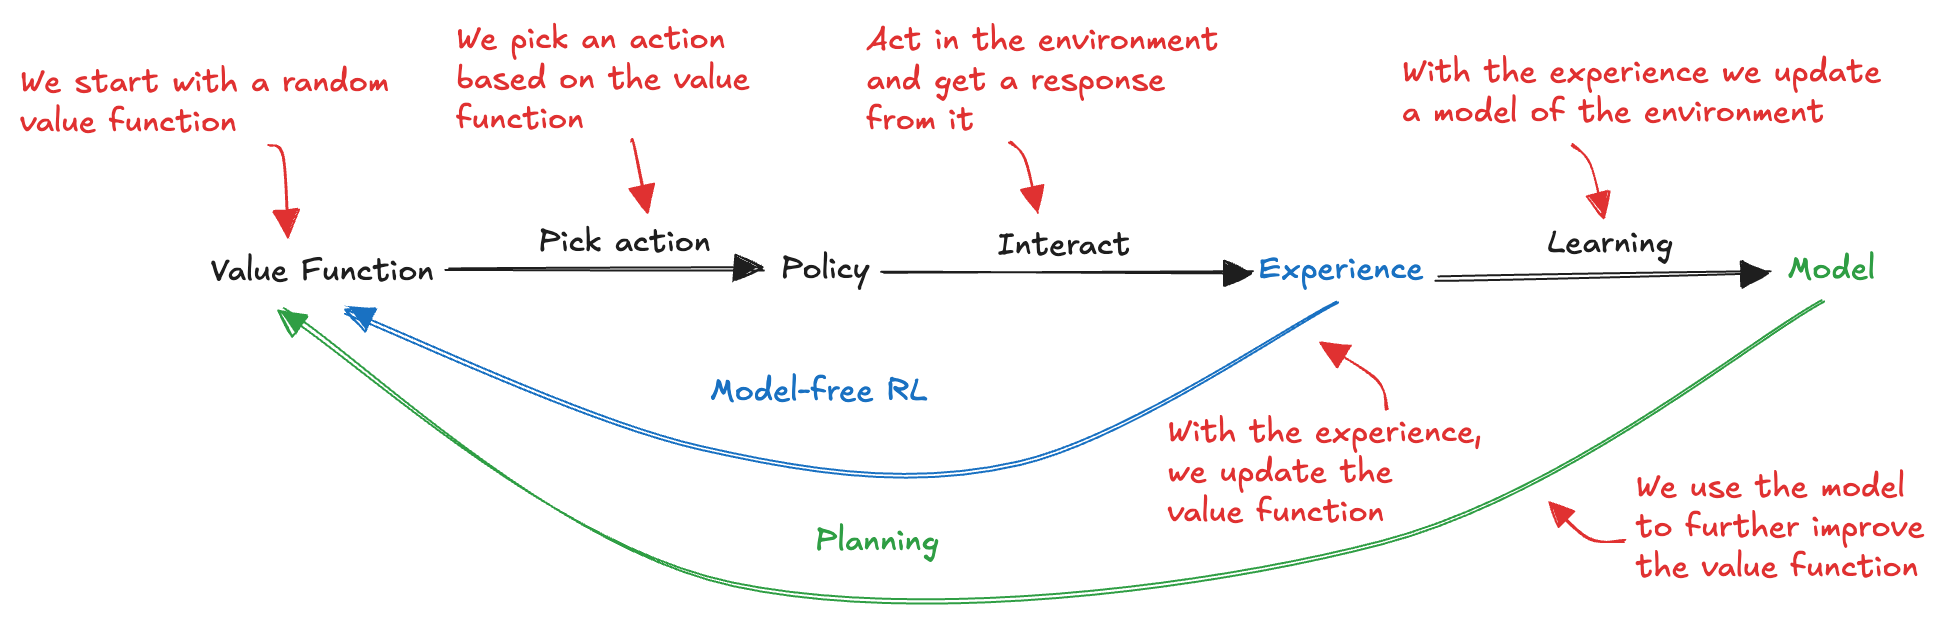

In pseudocode (adapted from the *Tabular Dyna-Q* of Sutton & Barto; the tilde marks simulated quantities):

```
Initialise Q(s,a) = 0, N(s,a,s') = 0, r̂(s,a,s') = 0 for all s, a, s'
for each episode:
    S ← initial state
    repeat until S is terminal:
        A ← ε-greedy(S, Q)                                            (a) act
        take A, observe R, S'                                         (b) real experience
        N(S,A,S') ← N(S,A,S') + 1                                      (c) model learning
        r̂(S,A,S') ← r̂(S,A,S') + [R − r̂(S,A,S')] / N(S,A,S')
        Q(S,A) ← Q(S,A) + α [R + γ max_a Q(S',a) − Q(S,A)]             (d) direct RL
        repeat n times:                                               (e) planning
            S̃ ← random previously visited state
            Ã ← random action previously taken in S̃
            S̃' ~ p̂(· | S̃, Ã),   R̃ ← r̂(S̃, Ã, S̃')
            Q(S̃,Ã) ← Q(S̃,Ã) + α [R̃ + γ max_a Q(S̃',a) − Q(S̃,Ã)]
        S ← S'
```

With $n = 0$ the algorithm is exactly the Q-learning of Chapter 05: planning is an add-on to a model-free learner. Two remarks on our implementation. Sutton & Barto present Dyna-Q for deterministic environments, where the model simply stores the last observed $(R, S')$ for each pair; the counting model of the previous section is the natural generalisation to stochastic environments such as the Slippery Walk. Moreover, the model stores no termination flag: the target uses $\max_a Q(S',a)$ even when $S'$ is terminal, which is correct only because $Q(\text{terminal}, \cdot)$ is initialised to zero and never updated (a terminal state is never the starting point of a transition, real or simulated). This is the same convention we adopted in Chapter 05.

To implement Dyna-Q we need to decay $\alpha$ and $\varepsilon$ over the episodes, using the same function already used several times:

In [3]:
def decay_schedule(init_value, min_value, decay_steps, max_steps):

    # calculate the number of the remaining steps after the decay
    rem_steps = max_steps - decay_steps;

    # logspace returns numbers spaced evenly on a log scale
    # base^start is the starting value of the sequence,
    # base^stop is the final value of the sequence
    # num is the number of values to generate
    # base is the base of the log space
    values = np.logspace(start=0, stop=-2, num=decay_steps, base=10);

    # because the values may not end exactly at 0, given it’s the log, 
    # we change them to be between 0 and 1 so that the curve looks smooth and nice.
    values = (values - values.min()) / (values.max() - values.min());

    # linear transformation and get points between init_value and min_value
    values = (init_value - min_value) * values + min_value;

    # repeats the rightmost value rem_step number of times
    values = np.pad(values, (0, rem_steps), 'edge');

    return values;

Again we need to explore, and we use the decaying $\varepsilon$-greedy approach to control the exploration:

In [4]:
def select_action(state, q, epsilon=0.1):

    # if the random number is greater than epsilon, 
    if np.random.uniform() > epsilon:
        # pick the action with the highest Q value
        action = np.argmax(q[state]);
    else:
        # otherwise, pick a random action
        action = np.random.randint(len(q[0]));

    return action;

Then we can implement the Dyna-Q algorithm. The letters in the comments refer to the steps of the pseudocode:

In [5]:
def dyna_q(env, gamma=0.99,
           init_alpha=0.5, min_alpha=0.01,
           init_epsilon=1.0, min_epsilon=0.1,
           n_planning=5,
           decay_episodes=1000, n_episodes=3000):

    # calculate the learning rate schedule for all episodes
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the model: the transition counts N(s,a,s') and the mean rewards r(s,a,s')
    transitions = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=int);
    rewards = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=float);

    # create a list to save copies of the model and of the planning
    # decisions for offline analysis
    transitions_track = [];
    planning_track = [];

    # the episode loop
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:

            # (a) select the action, as in Q-learning
            action = select_action(state, q, epsilons[e]);

            # (b) step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;

            # (c) model learning: increment the count N(s,a,s') of the triplet
            # and update the incremental mean of the reward r(s,a,s')
            transitions[state][action][next_state] += 1;
            difference = reward - rewards[state][action][next_state];
            rewards[state][action][next_state] += (difference / transitions[state][action][next_state]);

            # (d) direct RL: the usual Q-learning update (off-policy, using the max)
            # on the real transition
            dyna_target = reward + gamma * q[next_state].max();
            dyna_error = dyna_target - q[state][action];
            q[state][action] = q[state][action] + alphas[e] * dyna_error;

            # (e) planning: n_planning Q-learning updates on simulated transitions
            for _ in range(n_planning):

                # make sure there have been updates to the Q-function before,
                # otherwise there is not much to plan
                if not np.any(q):
                    break;

                # search control: pick uniformly at random a state already
                # visited by the agent...
                visited_states = np.where(np.sum(transitions, axis=(1, 2)) > 0)[0];
                s_p = np.random.choice(visited_states);

                # ...and an action already taken in that state
                actions_taken = np.where(np.sum(transitions[s_p], axis=1) > 0)[0];
                a_p = np.random.choice(actions_taken);

                # sample the next state from the learned transition model p(.|s,a)
                probs = transitions[s_p][a_p] / transitions[s_p][a_p].sum();
                ns_p = np.random.choice(env.observation_space, p=probs);

                # read the reward from the learned reward model r(s,a,s')
                r_p = rewards[s_p][a_p][ns_p];

                # save the planning decision for offline analysis
                planning_track.append((s_p, a_p, r_p, ns_p));

                # update the Q-function using the simulated experience,
                # with exactly the same rule used for the real one
                dyna_target = r_p + gamma * q[ns_p].max();
                dyna_error = dyna_target - q[s_p][a_p];
                q[s_p][a_p] = q[s_p][a_p] + alphas[e] * dyna_error;

            # move to the next state
            state = next_state;

        # extract the state-value function
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save the value functions and the transitions model for analysis
        v_track[e] = v;
        transitions_track.append(transitions.copy());

    return q, v, pi, v_track, transitions_track, np.array(planning_track), rewards;

We apply Dyna-Q to the Slippery Walk environment and look at the estimates of the state-value function over the episodes:

In [6]:
np.random.seed(0); random.seed(0);   # for reproducibility of the plots below
q_dyna, v_dyna, pi_dyna, v_track_dyna, transitions_track_dyna, planning_dyna, rewards_dyna = dyna_q(slippery_walk)

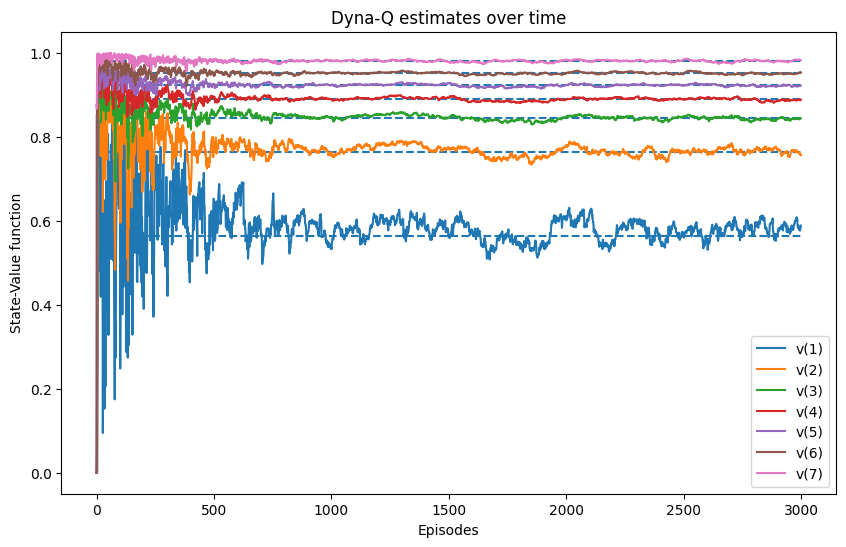

In [7]:
import matplotlib.pyplot as plt
legends = ['v(1)','v(2)','v(3)','v(4)','v(5)', 'v(6)', 'v(7)'];
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, len(v_track_dyna), linestyle='--');
lines = plt.plot(v_track_dyna[:,1:8]);
plt.title('Dyna-Q estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(lines, legends);
plt.show();

The estimates converge to the optimal values (dashed lines). The interesting question is whether they converge *faster* than plain Q-learning: Dyna-Q learns from both real and simulated experience, so every real step is exploited several times, and this is particularly valuable in applications where interacting with the environment is expensive, slow or dangerous, such as robotics. We postpone the quantitative comparison to the end of the chapter, after having introduced a second planning algorithm.

Two limitations, however, are already visible from the pseudocode. The performance depends on the **accuracy of the learned model**: if the model is wrong, planning propagates the error into the value function and the agent may make poor decisions. This is especially problematic in **changing environments**, where transitions that were learned correctly become stale; Dyna-Q has no mechanism to notice this, and a classical remedy (**Dyna-Q+**, Sutton & Barto §8.3) adds to the simulated reward an exploration bonus $\displaystyle \kappa \sqrt{\tau}$ that grows with the time $\tau$ elapsed since the pair was last tried in the real environment, encouraging the agent to re-check old parts of the model. Moreover, planning costs **computation**: $n$ extra updates per real step, which is the price we pay for needing fewer real samples.

To check the model of the environment learned by Dyna-Q, we can plot a 3D graph of the estimated transition probabilities $\hat p(s' \mid s, a)$ at different episodes. One axis is the initial state $s$, the other is the landing state $s'$, the colours are the actions and the bar heights are the estimated probabilities (pairs never tried have no bar):

In [8]:
def plot_transition_model(transitions):

    # normalise the counts row by row: p(s'|s,a) = N(s,a,s') / N(s,a);
    # pairs never tried (N(s,a) = 0) give 0/0, we show them as zero-height bars
    with np.errstate(divide='ignore', invalid='ignore'):
        transitions_prob = np.nan_to_num(transitions / transitions.sum(axis=2, keepdims=True));

    fig = plt.figure(figsize=(20,12));
    ax = fig.add_subplot(111, projection='3d');
    ax.view_init(elev=20, azim=50);

    plt.title('Learned MDP');
    ax.set_xlabel('Landing state');
    ax.set_ylabel('Initial state');
    ax.set_zlabel('Transition probabilities');
    ax.set_xlim(-0.5, transitions.shape[0] - 0.5);
    ax.set_ylim(-0.5, transitions.shape[0] - 0.5);
    ax.set_zlim(0, 1);

    x_data, y_data = np.meshgrid(range(transitions.shape[0]), range(transitions.shape[0]));
    x_data = x_data.flatten();
    y_data = y_data.flatten();
    left_data = transitions_prob[:, 0, :].flatten();
    right_data = transitions_prob[:, 1, :].flatten();

    # draw only the pairs that have been observed (non-zero estimated probability);
    # the two actions are drawn side by side, each bar is a probability in [0, 1]
    l = left_data > 0; r = right_data > 0;
    if l.any(): ax.bar3d(x_data[l] - 0.3, y_data[l], np.zeros_like(left_data[l]), 0.25, 0.25, left_data[l], color='yellow', shade=True);
    if r.any(): ax.bar3d(x_data[r] + 0.05, y_data[r], np.zeros_like(right_data[r]), 0.25, 0.25, right_data[r], color='red', shade=True);

    left_proxy = plt.Rectangle((0, 0), 1, 1, fc='yellow');
    right_proxy = plt.Rectangle((0, 0), 1, 1, fc='red');
    plt.legend((left_proxy, right_proxy), ('Left', 'Right'));

    plt.show();

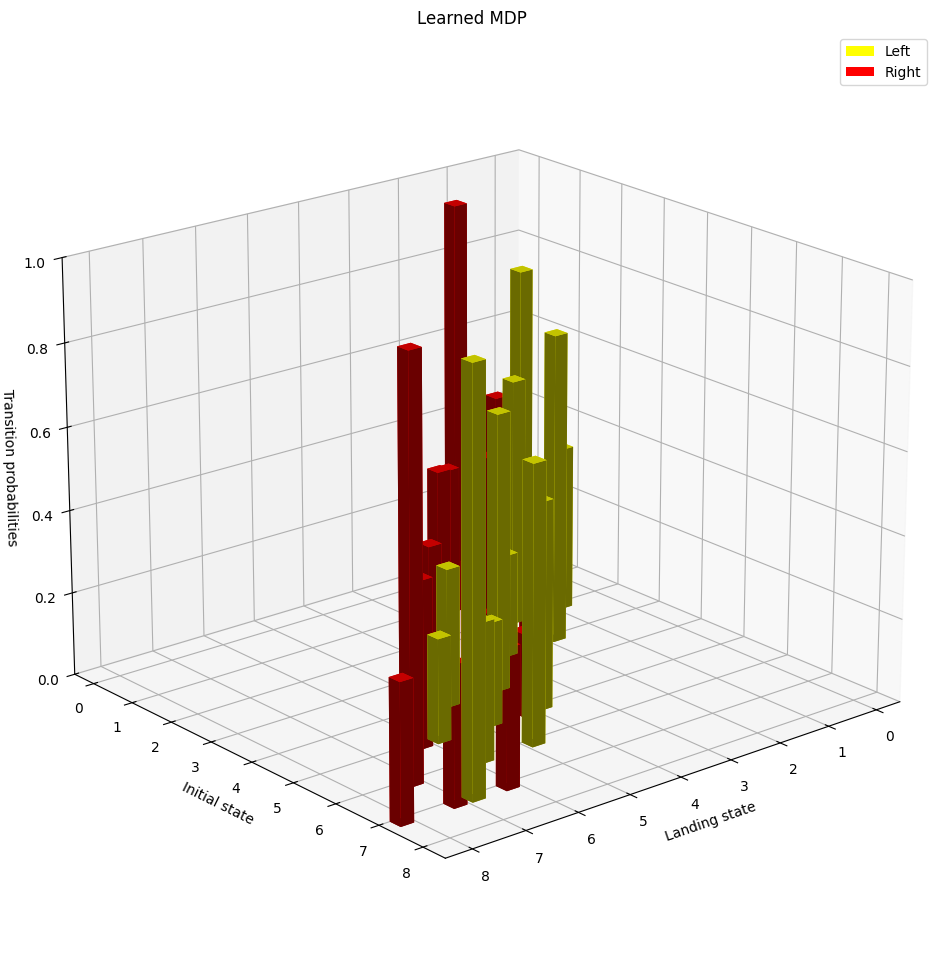

In [9]:
plot_transition_model(transitions_track_dyna[0]);

This is the model that Dyna-Q has learned after a single episode. Several transitions are missing and the observed ones have probability $1$, because each pair has been tried once: planning with this model early on is biased by its errors, which is the first limitation mentioned above.

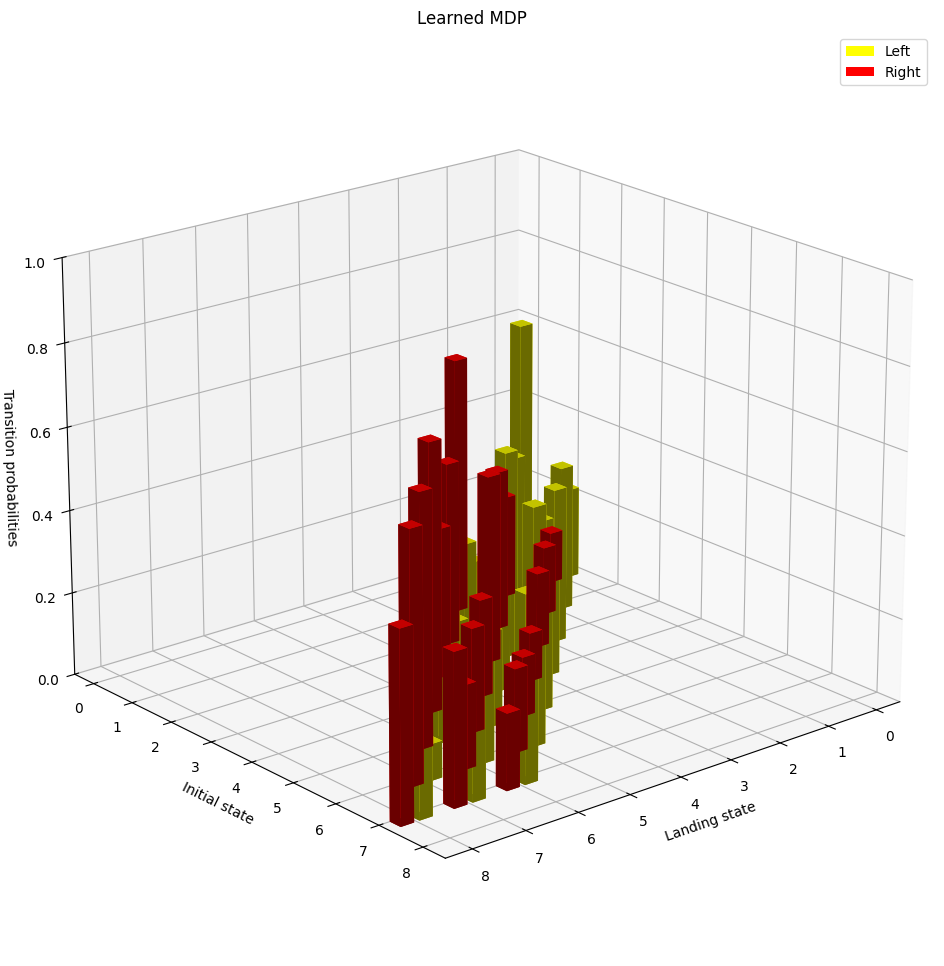

In [10]:
plot_transition_model(transitions_track_dyna[10]);

After only 10 episodes the model is taking shape and the probabilities start to look right.

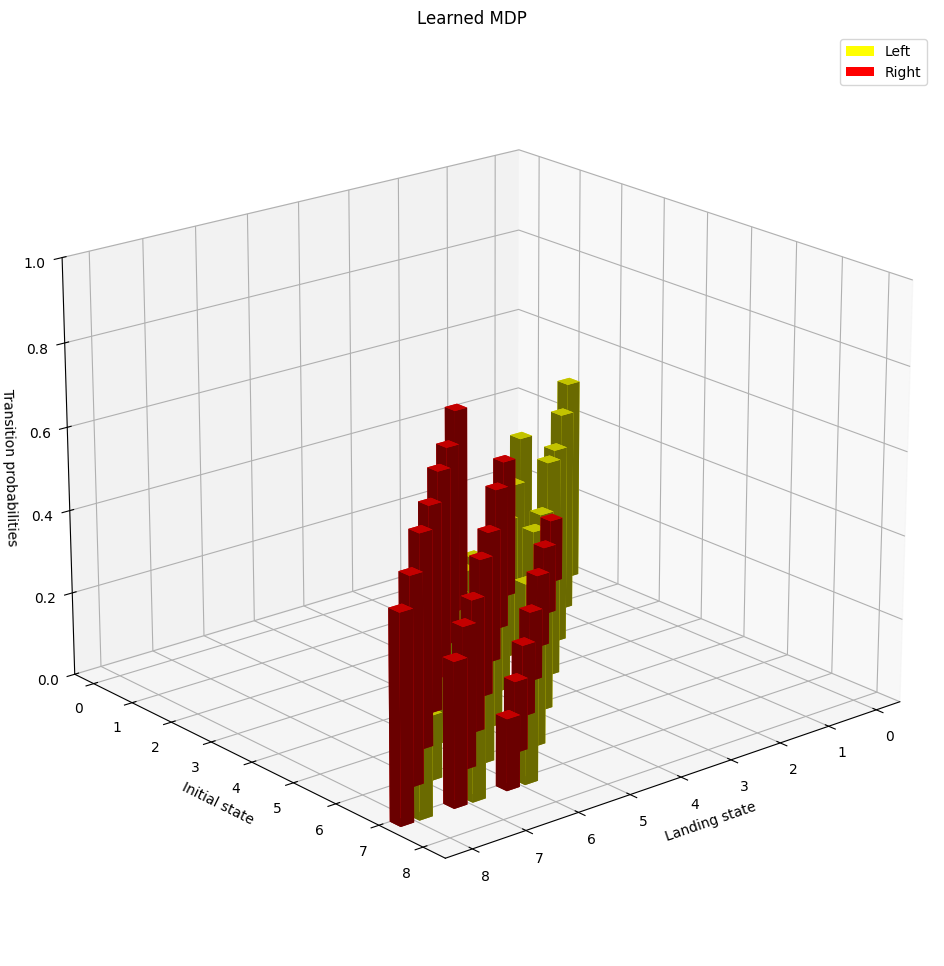

In [11]:
plot_transition_model(transitions_track_dyna[len(transitions_track_dyna)-1]);

At the end the estimates match the true probabilities ($1/2$ intended direction, $1/3$ stay, $1/6$ opposite direction) and describe the MDP correctly. Obviously this is a simple environment, so the agent quickly gathers enough experience samples to build an accurate model.

## Planning as Dynamic Programming on the learned model

The three snapshots above show the model getting better; we can now ask the natural question: **is the learned model good enough to plan with?** The most direct test is to treat $\hat p$ and $\hat r$ as if they were the true dynamics and run the **value iteration** of Chapter 03 on them, i.e. to iterate the expected backup of the section *Planning with a learned model* until convergence,

$\displaystyle V_{k+1}(s) = \max_a \sum_{s'} \hat p(s' \mid s, a) \Big[ \hat r(s,a,s') + \gamma\, V_k(s') \Big]$

This is planning in its purest form: no interaction, no sampling, no step size, just Dynamic Programming on the estimated MDP. Its output is the optimal value function *of the learned model*, which coincides with $v_*$ exactly when the model is exact:

In [12]:
def value_iteration_on_model(transitions, rewards, gamma=0.99, theta=1e-10):

    # turn the counts into the estimated transition function p(s'|s,a);
    # pairs never tried (0/0) get probability zero and therefore value zero
    with np.errstate(divide='ignore', invalid='ignore'):
        p_hat = np.nan_to_num(transitions / transitions.sum(axis=2, keepdims=True));

    # initialize a state-value function
    v = np.zeros(transitions.shape[0]);

    while True:
        # expected backup on the learned model, for every pair (s,a) at once:
        # q[s,a] = sum_s' p_hat[s,a,s'] * (rewards[s,a,s'] + gamma * v[s'])
        q = np.sum(p_hat * (rewards + gamma * v[None, None, :]), axis=2);

        # stop when the state-value function no longer changes
        if np.max(np.abs(v - np.max(q, axis=1))) < theta:
            break;

        v = np.max(q, axis=1);

    # extract the greedy policy with respect to the model
    def pi(s):
        return np.argmax(q[s]);

    return v, pi

In [13]:
v_model_10, _ = value_iteration_on_model(transitions_track_dyna[10], rewards_dyna);
v_model_end, _ = value_iteration_on_model(transitions_track_dyna[-1], rewards_dyna);

print('state             ', '  '.join('{:>6d}'.format(s) for s in range(1, 8)));
print('v* (true MDP)     ', '  '.join('{:6.3f}'.format(x) for x in optimal_v[1:8]));
print('VI, model @ ep 10 ', '  '.join('{:6.3f}'.format(x) for x in v_model_10[1:8]));
print('VI, model @ end   ', '  '.join('{:6.3f}'.format(x) for x in v_model_end[1:8]));
print('Dyna-Q estimate   ', '  '.join('{:6.3f}'.format(x) for x in v_dyna[1:8]));

state                   1       2       3       4       5       6       7
v* (true MDP)       0.564   0.763   0.845   0.889   0.922   0.952   0.981
VI, model @ ep 10   0.642   0.781   0.851   0.910   0.934   0.956   0.979
VI, model @ end     0.571   0.761   0.842   0.887   0.921   0.950   0.980
Dyna-Q estimate     0.588   0.756   0.844   0.888   0.922   0.952   0.981


Two lessons. First, **the quality of a plan is bounded by the quality of the model**: value iteration is exact, yet on the model learned after 10 episodes it returns values that are off by up to several hundredths, simply because the estimated probabilities are wrong. The direction of the error depends on which transitions happened to be observed: with a different seed you may see states over-estimated (the few transitions seen from them were lucky) or states with value exactly zero (no path from them to the goal has been observed yet, so in the model they *cannot* reach it). The planner has no way of knowing this: it computes the exact optimal values of a wrong MDP. Second, with the final model the planner recovers $v_*$ to within the sampling error of the counts, and it does so with a handful of sweeps and no learning rate, while Dyna-Q needed thousands of noisy incremental updates to get to a comparable accuracy. This is the trade-off between the two kinds of backup: expected backups are exact and fast when a good distribution model is available, sample backups are cheap and work with any sample model. Here, with only 18 state–action pairs, one could simply plan by value iteration after every real step; Dyna-Q's sampled planning is the version that survives when the state space is large (its cost does not grow with $|\mathcal{S}|$ per update) and it is the starting point for the deep model-based methods.

## Making plans for the immediate future: Trajectory sampling

The search control of Dyna-Q is uniform: a state is drawn uniformly at random among the visited ones, then an action uniformly among those tried in it. This distributes the planning effort evenly over everything the agent has seen, including states that are irrelevant for the current policy. Planning can be more effective if we spend it on **the states that the agent is about to encounter**, obtained by following the current policy *through the model*: starting from the state the agent has just reached, we simulate a short trajectory, choosing the actions either with the behaviour policy ($\varepsilon$-greedy, on-policy) or greedily with respect to the current estimates, and we update every simulated pair along the way. Sutton & Barto (§8.6) call this **trajectory sampling**: the simulated states are then distributed according to the on-policy state distribution rather than uniformly. The idea of concentrating value updates along the trajectories the agent actually follows was introduced by real-time dynamic programming ([A.G. Barto, S.J. Bradtke, S.P. Singh, "Learning to act using real-time dynamic programming", Artificial Intelligence, 1995](./papers/1995%20-%20Learning%20to%20act%20using%20real-time%20dynamic%20programming.pdf)), which performs full backups along real trajectories; here we keep the sample backups of Dyna-Q and only change the search control.

The code is the same as Dyna-Q, with two exceptions: the planning trajectory starts from the state the agent has just reached, and each simulated step follows the policy instead of picking a random visited pair. If the simulated trajectory hits a pair never tried in the real environment, the model has nothing to say about it and we stop planning for this step:

In [14]:
def trajectory_sampling(env, gamma=0.99,
                        init_alpha=0.5, min_alpha=0.01,
                        init_epsilon=1.0, min_epsilon=0.1,
                        n_planning=5, greedy_planning=False,
                        decay_episodes=1000, n_episodes=3000):

    # calculate the learning rate schedule for all episodes
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the model: the transition counts N(s,a,s') and the mean rewards r(s,a,s')
    transitions = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=int);
    rewards = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=float);

    # create a list to save copies of the model and of the planning
    # decisions for offline analysis
    transitions_track = [];
    planning_track = [];

    # the episode loop
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:

            # (a) select the action, as in Q-learning
            action = select_action(state, q, epsilons[e])

            # (b) step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;

            # (c) model learning, as in Dyna-Q
            transitions[state][action][next_state] += 1;
            difference = reward - rewards[state][action][next_state];
            rewards[state][action][next_state] += (difference / transitions[state][action][next_state]);

            # (d) direct RL, as in Dyna-Q
            ts_target = reward + gamma * q[next_state].max();
            ts_error = ts_target - q[state][action];
            q[state][action] = q[state][action] + alphas[e] * ts_error;

            # (e) planning: simulate a trajectory that starts from the state
            # the agent has just reached
            s_p = next_state;
            for _ in range(n_planning):

                # make sure there have been updates to the Q-function before,
                # otherwise there is not much to plan
                if not np.any(q):
                    break;

                # search control: follow the policy inside the model, either the
                # behaviour policy (on-policy) or the greedy policy
                if greedy_planning:
                    a_p = q[s_p].argmax();
                else:
                    a_p = select_action(s_p, q, epsilons[e]);

                # if we have never experienced this pair, the model cannot
                # simulate it: stop the simulated trajectory
                if not transitions[s_p][a_p].sum():
                    break;

                # sample the next state from the learned transition model, as in Dyna-Q
                probs = transitions[s_p][a_p] / transitions[s_p][a_p].sum();
                ns_p = np.random.choice(env.observation_space, p=probs);

                # read the reward from the learned reward model, as in Dyna-Q
                r_p = rewards[s_p][a_p][ns_p];

                # save the planning decision for offline analysis
                planning_track.append((s_p, a_p, r_p, ns_p));

                # update the Q-function using the simulated experience
                ts_target = r_p + gamma * q[ns_p].max();
                ts_error = ts_target - q[s_p][a_p];
                q[s_p][a_p] = q[s_p][a_p] + alphas[e] * ts_error;

                # continue the simulated trajectory from the simulated next state
                s_p = ns_p;

            # move to the next (real) state
            state = next_state;

        # extract the state-value function
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save the value functions and the transitions model for analysis
        v_track[e] = v;
        transitions_track.append(transitions.copy());

    return q, v, pi, v_track, transitions_track, np.array(planning_track), rewards;

We apply the new algorithm to the Slippery Walk environment:

In [15]:
np.random.seed(0); random.seed(0);
q_ts, v_ts, pi_ts, v_track_ts, transitions_track_ts, planning_ts, rewards_ts = trajectory_sampling(slippery_walk);

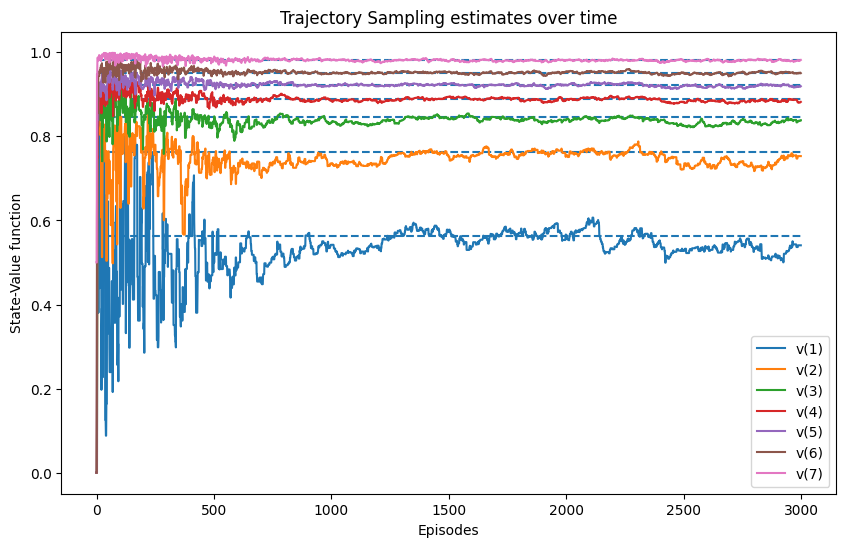

In [16]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, len(v_track_ts), linestyle='--');
lines = plt.plot(v_track_ts[:,1:8]);
plt.title('Trajectory Sampling estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(lines, legends);
plt.show();

Uniform sampling spreads the planning effort over all the visited pairs; trajectory sampling concentrates it on the pairs that the current policy is likely to visit. Sutton & Barto (§8.6) show that focusing on the on-policy distribution is typically an advantage early on (the pairs that matter for the current policy are updated many times) and can become a disadvantage in the long run (the pairs that the policy avoids are never re-examined, so an improvement hiding there can be missed). Which effect prevails depends on the problem and is best assessed empirically, as we do in the comparison at the end of the chapter. What we can verify directly is the difference in *where* the two algorithms plan: we plot the states sampled by the planning phase and the actions selected in those states:

In [17]:
from matplotlib.patches import Patch

def plot_state_action_sampling(planning, algo):
    plt.figure(figsize=(10,6));
    plt.title('States sampled in planning by {}'.format(algo));
    plt.xlabel('Initial state of the simulated transition');
    plt.ylabel('Count');
    for s in np.arange(9):
        actions = planning[np.where(planning[:,0]==s)[0], 1];
        left = len(actions[actions == 0]);
        right = len(actions[actions == 1]);
        # same colours as in the 3D plot of the model: yellow = Left, red = Right
        plt.bar(s, left, 0.5, color='yellow', edgecolor='black');
        plt.bar(s, right, 0.5, color='red', edgecolor='black', bottom=left);
    plt.legend(handles=[Patch(facecolor='yellow', edgecolor='black', label='Left'),
                        Patch(facecolor='red', edgecolor='black', label='Right')]);
    plt.show();

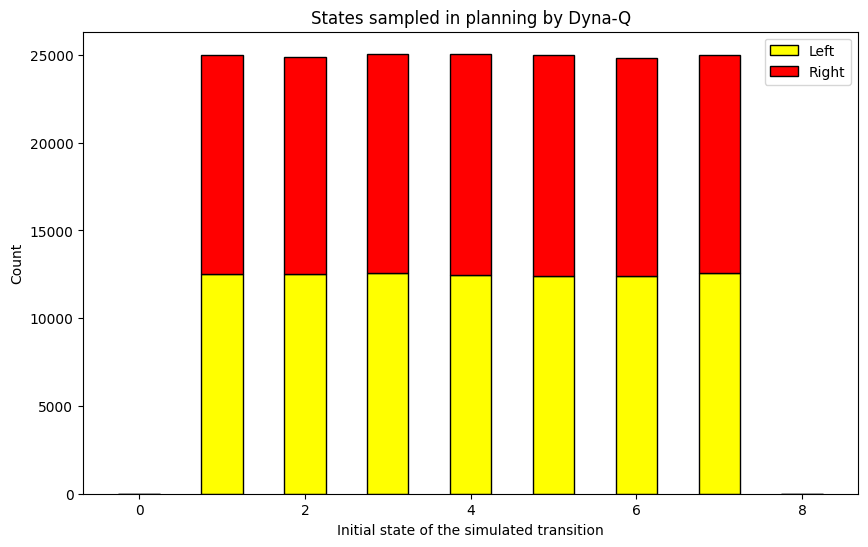

In [18]:
plot_state_action_sampling(planning_dyna, algo='Dyna-Q')

Dyna-Q samples uniformly at random both the states and the actions taken in them: the counts are flat over the seven non-terminal states and split evenly between Left and Right.

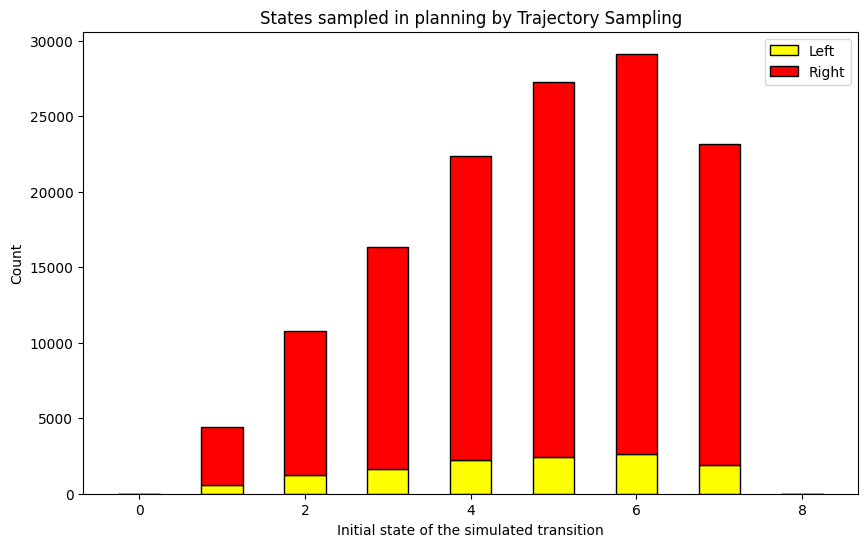

In [19]:
plot_state_action_sampling(planning_ts, algo='Trajectory Sampling')

Trajectory sampling follows the current (mostly greedy) policy inside the model, and the greedy action is Right almost everywhere, since the rightmost terminal state is the only source of reward. The sampled states are therefore skewed toward the goal, and Right is sampled far more than Left across the board. In this way trajectory sampling **lands on the goal state far more often, experiencing non-zero rewards from the model more frequently**, and concentrates its updates on the pairs that determine the greedy policy.

## Focusing planning where the value is wrong: Prioritized sweeping

Trajectory sampling plans where the agent *goes*. A different answer to the search-control question is to plan where the value function is *wrong*. Consider what happens when a real transition changes $Q(s,a)$ by a large amount, for instance when the agent first reaches the goal: only the pairs whose successor may be $s$, its **predecessors** in the model, are directly affected, and only those deserve an update right now. Updating them may in turn change their values, so their own predecessors become urgent, and so on: the information flows *backwards* from the goal, one layer of predecessors at a time. **Prioritized sweeping** ([Moore & Atkeson, 1993](https://doi.org/10.1007/BF00993104); Sutton & Barto §8.4) implements exactly this with a **priority queue** of state–action pairs, ordered by how much their value is expected to change.

To measure the urgency of a pair we use the **Bellman residual on the learned model**, the difference between the expected backup and the current estimate,

$\displaystyle \delta(s,a) = \sum_{s'} \hat p(s' \mid s, a) \Big[ \hat r(s,a,s') + \gamma \max_{a'} Q(s',a') \Big] - Q(s,a), \qquad P(s,a) = \lvert \delta(s,a) \rvert$

A pair enters the queue when $P(s,a)$ exceeds a small threshold $\theta$ (the same role as the stopping tolerance of Chapter 03). Planning repeatedly pops the pair with the highest priority, applies the expected backup $Q(s,a) \leftarrow Q(s,a) + \alpha\, \delta(s,a)$, and then recomputes the priority of all its predecessors, i.e. of every pair $(\bar s, \bar a)$ with $N(\bar s, \bar a, s) > 0$, inserting those above threshold; the same is done after the direct RL update of the real pair, whose value has changed too. In pseudocode:

```
Initialise Q, N, r̂ as in Dyna-Q;  PQueue ← empty
for each episode:
    S ← initial state
    repeat until S is terminal:
        A ← ε-greedy(S, Q);  take A, observe R, S'                        (a)(b) real experience
        update the model N(S,A,S'), r̂(S,A,S')                              (c) model learning
        Q(S,A) ← Q(S,A) + α [R + γ max_a Q(S',a) − Q(S,A)]                  (d) direct RL
        push(S,A);  push every predecessor (S̄,Ā) of S, i.e. every pair with N(S̄,Ā,S) > 0
        repeat n times, while PQueue is not empty:                         (e) planning
            (S̃,Ã) ← pop the pair with the highest priority
            Q(S̃,Ã) ← Q(S̃,Ã) + α δ(S̃,Ã)                                       expected backup on the model
            push(S̃,Ã);  push every predecessor (S̄,Ā) of S̃
        S ← S'

where push(s,a):  P ← |δ(s,a)|;  if P > θ, insert (s,a) in PQueue with priority P (or raise its priority)
```

The rule is uniform: **whenever the value of a state changes**, by a real or by a simulated update, the pairs that lead to it are re-examined, and a pair stays in the queue as long as its residual exceeds $\theta$.

Sutton & Barto present the algorithm for deterministic environments, where the priority is the TD error of a single stored transition. In a stochastic environment such as ours a single-transition error never vanishes (it compares one successor with an average over successors), so the queue would never empty; the expected residual $\delta$ instead goes to zero as the estimates approach the fixed point of the learned model, which is what we want. Finding the predecessors is cheap in the tabular case: they are the non-zero entries of the column `transitions[:, :, s]`. For the queue we use a plain dictionary and take its maximum, which is fine for a few dozen pairs (a heap would be used for large problems):

In [20]:
def prioritized_sweeping(env, gamma=0.99,
                         init_alpha=0.5, min_alpha=0.01,
                         init_epsilon=1.0, min_epsilon=0.1,
                         n_planning=5, theta=1e-3,
                         decay_episodes=1000, n_episodes=3000):

    # calculate the learning rate schedule for all episodes
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the model: the transition counts N(s,a,s') and the mean rewards r(s,a,s')
    transitions = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=int);
    rewards = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=float);

    # create a list to save copies of the model and of the planning
    # decisions for offline analysis
    transitions_track = [];
    planning_track = [];

    # the priority queue: a dictionary (state, action) -> priority
    priorities = {};

    # the Bellman residual of a pair on the learned model:
    # expected backup minus current estimate
    def residual(s, a):
        probs = transitions[s][a] / transitions[s][a].sum();
        target = np.sum(probs * (rewards[s][a] + gamma * q.max(axis=1)));
        return target - q[s][a];

    # insert a pair in the queue if its priority is above threshold
    # (keeping the highest priority if it is already there)
    def push(s, a):
        priority = abs(residual(s, a));
        if priority > theta:
            priorities[(s, a)] = max(priority, priorities.get((s, a), 0));

    # the value of state s has changed: all the pairs observed to lead to s
    # (its predecessors in the model) may have become inconsistent
    def push_predecessors(s):
        pred_states, pred_actions = np.where(transitions[:, :, s] > 0);
        for s_b, a_b in zip(pred_states, pred_actions):
            push(s_b, a_b);

    # the episode loop
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:

            # (a) select the action, as in Q-learning
            action = select_action(state, q, epsilons[e]);

            # (b) step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;

            # (c) model learning, as in Dyna-Q
            transitions[state][action][next_state] += 1;
            difference = reward - rewards[state][action][next_state];
            rewards[state][action][next_state] += (difference / transitions[state][action][next_state]);

            # (d) direct RL, as in Dyna-Q
            ps_target = reward + gamma * q[next_state].max();
            ps_error = ps_target - q[state][action];
            q[state][action] = q[state][action] + alphas[e] * ps_error;

            # the value of `state` has changed: the pair itself (if still
            # inconsistent) and its predecessors are candidates for planning
            push(state, action);
            push_predecessors(state);

            # (e) planning: n_planning expected backups in priority order
            for _ in range(n_planning):

                # nothing urgent to update
                if not priorities:
                    break;

                # search control: pop the pair with the highest priority
                s_p, a_p = max(priorities, key=priorities.get);
                del priorities[(s_p, a_p)];

                # expected backup on the learned model
                q[s_p][a_p] = q[s_p][a_p] + alphas[e] * residual(s_p, a_p);

                # save the planning decision for offline analysis
                planning_track.append((s_p, a_p, -1, -1));

                # keep the pair if it is still inconsistent (alpha < 1), and
                # re-evaluate its predecessors, whose targets have just changed
                push(s_p, a_p);
                push_predecessors(s_p);

            # move to the next state
            state = next_state;

        # extract the state-value function
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save the value functions and the transitions model for analysis
        v_track[e] = v;
        transitions_track.append(transitions.copy());

    return q, v, pi, v_track, transitions_track, np.array(planning_track), rewards;

We apply prioritized sweeping to the Slippery Walk:

In [21]:
np.random.seed(0); random.seed(0);
q_ps, v_ps, pi_ps, v_track_ps, transitions_track_ps, planning_ps, rewards_ps = prioritized_sweeping(slippery_walk);

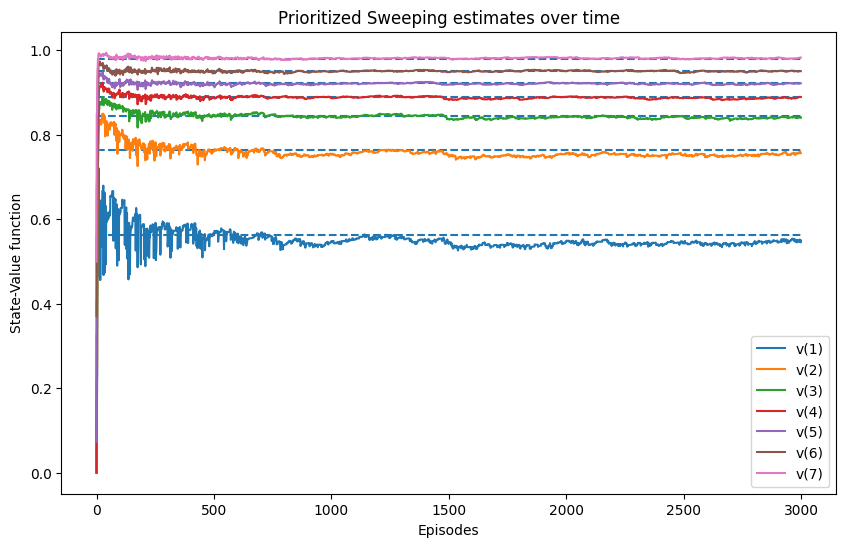

In [22]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, len(v_track_ps), linestyle='--');
lines = plt.plot(v_track_ps[:,1:8]);
plt.title('Prioritized Sweeping estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(lines, legends);
plt.show();

The estimates are visibly smoother than those of Dyna-Q and trajectory sampling: expected backups have no sampling noise. Where does prioritized sweeping spend its planning budget?

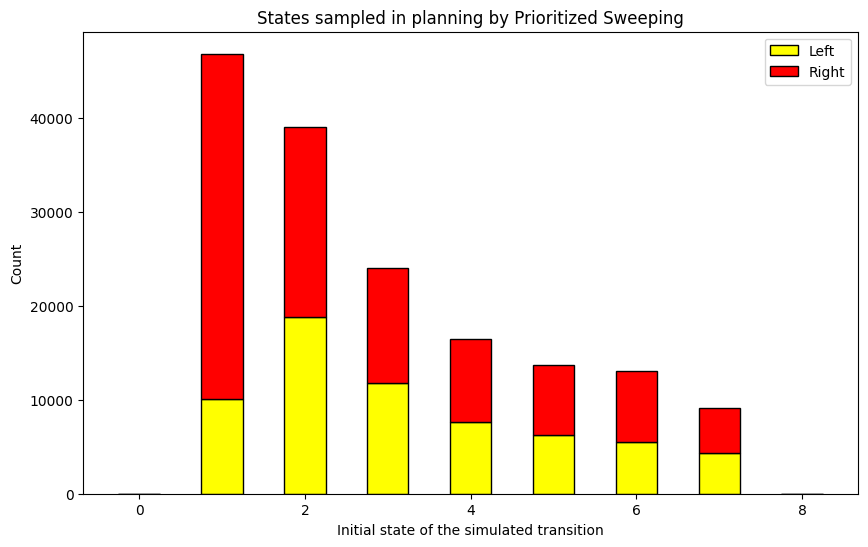

In [23]:
plot_state_action_sampling(planning_ps, algo='Prioritized Sweeping')

Neither uniform nor skewed toward the goal: the updates concentrate on the states **far from the goal**, whose values are the smallest, the noisiest and the slowest to converge, hence those with the largest Bellman residual. Trajectory sampling plans where the agent goes, prioritized sweeping plans where the value function is still wrong; the two criteria are complementary, and both beat uniform search control in large problems (Sutton & Barto report speed-ups of one to two orders of magnitude over Dyna-Q on maze tasks). The price is the bookkeeping: a queue, a predecessor lookup and an expected backup per planning step, which requires a distribution model.

## Does planning pay off? Comparison with Q-learning

We now measure what the chapter promised: that planning extracts more from each real experience sample. Since Dyna-Q with $n = 0$ planning steps is exactly Q-learning, we can run the same code with different values of $n$, add trajectory sampling and prioritized sweeping, and compare the mean absolute error between the estimated and the optimal state-value functions over the episodes (the horizontal axis counts *real* episodes, i.e. real experience). We average the curves over a few independent runs, because a single run is noisy:

In [24]:
def moving_average(a, n=100):
    ret = np.cumsum(a, dtype=float);
    ret[n:] = ret[n:] - ret[:-n];
    return ret[n - 1:] / n;

def mae_curve(algorithm, n_runs=3, **kwargs):
    # mean absolute error between v and v* over the non-terminal states,
    # averaged over n_runs independent runs
    curves = [];
    for run in range(n_runs):
        np.random.seed(run); random.seed(run);
        v_track = algorithm(slippery_walk, **kwargs)[3];
        curves.append(np.mean(np.abs(v_track[:, 1:8] - np.array(optimal_v)[1:8]), axis=1));
    return np.mean(curves, axis=0);

mae_q = mae_curve(dyna_q, n_planning=0);
mae_dyna_5 = mae_curve(dyna_q, n_planning=5);
mae_dyna_30 = mae_curve(dyna_q, n_planning=30);
mae_ts = mae_curve(trajectory_sampling, n_planning=5);
mae_ps = mae_curve(prioritized_sweeping, n_planning=5);

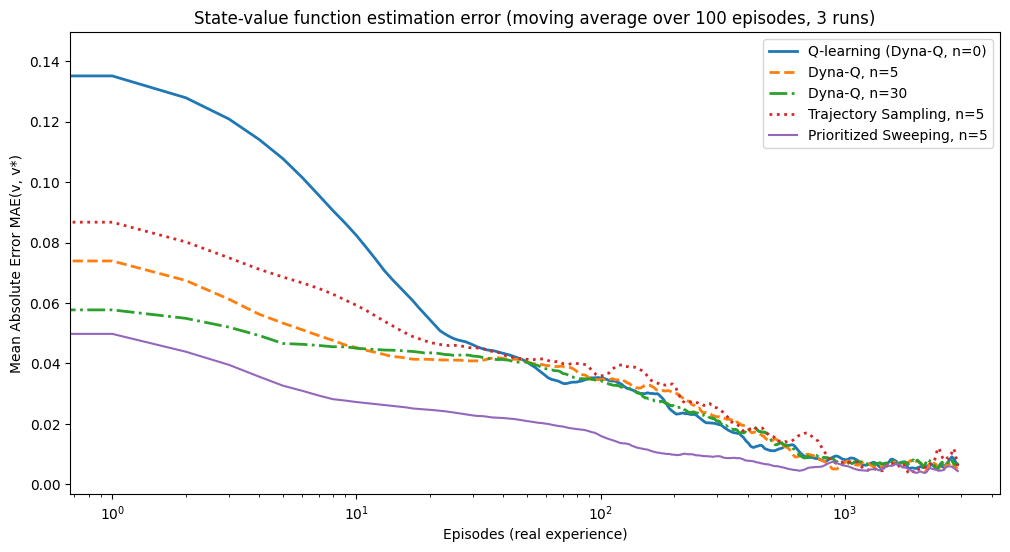

In [25]:
plt.figure(figsize=(12,6));
plt.plot(moving_average(mae_q), '-', linewidth=2, label='Q-learning (Dyna-Q, n=0)');
plt.plot(moving_average(mae_dyna_5), '--', linewidth=2, label='Dyna-Q, n=5');
plt.plot(moving_average(mae_dyna_30), '-.', linewidth=2, label='Dyna-Q, n=30');
plt.plot(moving_average(mae_ts), ':', linewidth=2, label='Trajectory Sampling, n=5');
plt.plot(moving_average(mae_ps), '-', linewidth=1.5, label='Prioritized Sweeping, n=5');
plt.xscale('log');
plt.legend();
plt.title('State-value function estimation error (moving average over 100 episodes, 3 runs)');
plt.xlabel('Episodes (real experience)');
plt.ylabel('Mean Absolute Error MAE(v, v*)');
plt.show();

The picture is instructive, and more nuanced than "planning is faster". In the **first episodes**, when real experience is scarce, planning makes a large difference: after a handful of episodes the error of plain Q-learning is about twice that of Dyna-Q, and Q-learning needs some ten to twenty real episodes to reach the accuracy that Dyna-Q has from the start. More planning steps help ($n = 30$ is better than $n = 5$ early on), with diminishing returns, since the simulated experience cannot contain more information than the real experience the model was built from. Trajectory sampling starts a little slower than Dyna-Q on this problem: with only seven states, uniform search control already covers everything that matters, and following the (initially random) policy through a model built from very few samples buys nothing. Prioritized sweeping is the best of the planners from the very first episodes to the end and reaches the lowest final error: it spends its updates exactly where the value function is still inconsistent with the model, and its expected backups have no sampling noise.

After a few tens of episodes **all the curves coincide**: once the agent has gathered enough real experience, the model no longer adds information, and the final error is determined by the floors of the schedules of $\alpha$ and $\varepsilon$, which are the same for all methods. The benefit of planning is therefore **sample efficiency where samples are scarce**, not a better asymptote. Remember also that the horizontal axis counts real episodes: in terms of computation Dyna-Q with $n = 30$ performed $31$ times more updates than Q-learning, the trade-off we announced at the beginning of the chapter. The Slippery Walk is a tiny problem in which real experience is cheap; the lab of this chapter repeats the comparison on the Frozen Lake, a larger environment with a sparser reward, where the same effect is more pronounced.

## When the world changes: Dyna-Q+

All the planners above assume a **stationary** environment: the counts accumulate forever, and the model converges to the dynamics it has seen. What if the environment changes? Planning then propagates a *wrong* model into the value function with great efficiency, and the more the agent trusts its model, the longer it takes to notice. Sutton & Barto illustrate this with mazes whose walls move (§8.3); we build the simplest analogue for the Slippery Walk: after a given episode, **the reward moves from the right end to the left end** of the walk. The agent has to discover that its whole policy is now wrong.

To cope with change an agent needs two ingredients. The first is a **model that can forget**. Our reward model is an incremental mean with step size $1/N(s,a,s')$: after thousands of observations of $r = 1$ into the right terminal state, a new observation of $r = 0$ moves the estimate by one part in thousands, so the model would take as long to unlearn the old reward as it took to learn it. The remedy is the one we used for non-stationary bandits in Chapter 04: a **constant step size** $\beta$, which turns the mean into an exponential recency-weighted average,

$\displaystyle \hat r(s,a,s') \leftarrow \hat r(s,a,s') + \beta \big[ R_{t+1} - \hat r(s,a,s') \big]$

The second ingredient is an **incentive to re-check** parts of the environment that have not been visited for a long time, because their model entries may be stale. **Dyna-Q+** adds to the reward of every *simulated* transition an exploration bonus that grows with the number of time steps $\tau(s,a)$ elapsed since the pair was last tried in the real environment,

$\displaystyle \tilde R = \hat r(s,a,s') + \kappa \sqrt{\tau(s,a)}$

with a small $\kappa$. Planning then makes long-unvisited pairs look attractive, the greedy policy is drawn to them, the real visit updates the model and resets $\tau(s,a)$ to zero. The bonus is only used in planning, never in the direct RL update, so the real values are not distorted; it is the same optimism-in-the-face-of-uncertainty principle of UCB (Chapter 04), applied to the model rather than to the value. First, the changing environment; the `episode` counter is bumped at each reset, and the reward flips after `change_episode`:

In [26]:
class ChangingSlipperyWalk(SlipperyWalk):

    def __init__(self, change_episode=1500):
        self.change_episode = change_episode;
        self.episode = 0;
        super().__init__();

    def reset(self):
        self.episode += 1;
        return super().reset();

    def step(self, action):
        if self.terminated: raise ValueError('Episode has terminated');
        if action not in [0, 1]: raise ValueError('Invalid action');

        if(action==0): direction = -1;
        if(action==1): direction = 1;

        direction_list = [direction, -direction, 0];
        true_direction = random.choices(direction_list, weights=(3, 1, 2), k=1);
        self.state += true_direction[0];

        # before the change the reward is on the right end, after it on the left end
        changed = self.episode > self.change_episode;
        reward = 0;
        if self.state < 1: self.terminated = True; reward = 1 if changed else 0;
        if self.state > 7: self.terminated = True; reward = 0 if changed else 1;
        return self.state, reward, self.terminated, 0, 0;

Then Dyna-Q+. The code is Dyna-Q with two additions, a constant step size `beta` for the reward model (`None` keeps the incremental mean) and the bonus coefficient `kappa` (`0` disables it), so that `dyna_q_plus(env)` with the defaults is exactly Dyna-Q. We also record the return of every episode, which is the natural performance measure when the target itself moves:

In [27]:
def dyna_q_plus(env, gamma=0.99,
                init_alpha=0.5, min_alpha=0.01,
                init_epsilon=1.0, min_epsilon=0.1,
                n_planning=5, kappa=0.0, beta=None,
                decay_episodes=1000, n_episodes=3000):

    # schedules, Q-function, model and tracking, as in Dyna-Q
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    transitions = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=int);
    rewards = np.zeros((env.observation_space, env.action_space, env.observation_space), dtype=float);
    returns = np.zeros(n_episodes, dtype=float);

    # time step of the last real visit of each pair, and the global time step
    last_visit = np.zeros((env.observation_space, env.action_space), dtype=int);
    t = 0;

    for e in range(n_episodes):
        state, done = env.reset(), False;
        while not done:
            t += 1;

            # (a)(b) act and observe
            action = select_action(state, q, epsilons[e]);
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            returns[e] += reward;

            # (c) model learning: counts as before; the reward model uses either the
            # incremental mean (beta=None) or a constant step size (recency-weighted)
            transitions[state][action][next_state] += 1;
            last_visit[state][action] = t;
            step_size = beta if beta is not None else 1.0 / transitions[state][action][next_state];
            difference = reward - rewards[state][action][next_state];
            rewards[state][action][next_state] += step_size * difference;

            # (d) direct RL, on the real reward (no bonus here)
            dyna_target = reward + gamma * q[next_state].max();
            q[state][action] = q[state][action] + alphas[e] * (dyna_target - q[state][action]);

            # (e) planning, as in Dyna-Q, but the simulated reward carries the bonus
            for _ in range(n_planning):
                if not np.any(q):
                    break;
                visited_states = np.where(np.sum(transitions, axis=(1, 2)) > 0)[0];
                s_p = np.random.choice(visited_states);
                actions_taken = np.where(np.sum(transitions[s_p], axis=1) > 0)[0];
                a_p = np.random.choice(actions_taken);
                probs = transitions[s_p][a_p] / transitions[s_p][a_p].sum();
                ns_p = np.random.choice(env.observation_space, p=probs);

                # exploration bonus: the longer since the pair was really tried, the larger
                tau = t - last_visit[s_p][a_p];
                r_p = rewards[s_p][a_p][ns_p] + kappa * np.sqrt(tau);

                dyna_target = r_p + gamma * q[ns_p].max();
                q[s_p][a_p] = q[s_p][a_p] + alphas[e] * (dyna_target - q[s_p][a_p]);

            state = next_state;

    def pi(s):
        return np.argmax(q[s]);

    return q, pi, returns;

We compare four agents on the changing walk: plain Dyna-Q, Dyna-Q with a recency-weighted reward model ($\beta = 0.2$, no bonus), Dyna-Q+ with a small bonus ($\kappa = 0.001$) and Dyna-Q+ with a large bonus ($\kappa = 0.01$). The reward moves at episode 1500; we plot the moving average of the return per episode (1 = the agent reached the rewarding end):

Dyna-Q                                        greedy policy after the change: RLLLLLR


Dyna-Q, recency-weighted model (beta=0.2)     greedy policy after the change: LLLLLLL


Dyna-Q+ (beta=0.2, kappa=0.001)               greedy policy after the change: LLLLLLL


Dyna-Q+ (beta=0.2, kappa=0.01)                greedy policy after the change: RRRLLLL


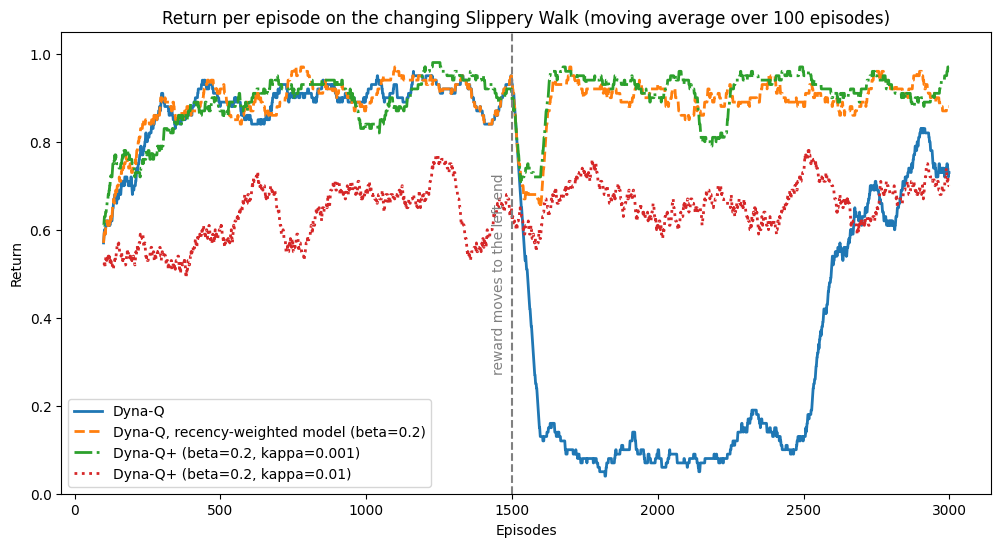

In [28]:
variants = [('Dyna-Q', dict()),
            ('Dyna-Q, recency-weighted model (beta=0.2)', dict(beta=0.2)),
            ('Dyna-Q+ (beta=0.2, kappa=0.001)', dict(beta=0.2, kappa=0.001)),
            ('Dyna-Q+ (beta=0.2, kappa=0.01)', dict(beta=0.2, kappa=0.01))];

plt.figure(figsize=(12,6));
for (name, kwargs), style in zip(variants, ['-', '--', '-.', ':']):
    np.random.seed(0); random.seed(0);
    q_c, pi_c, returns_c = dyna_q_plus(ChangingSlipperyWalk(change_episode=1500), **kwargs);
    plt.plot(np.arange(99, len(returns_c)), moving_average(returns_c), style, linewidth=2, label=name);
    print('{:45s} greedy policy after the change: {}'.format(name, ''.join('L' if pi_c(s)==0 else 'R' for s in range(1, 8))));
plt.axvline(1500, color='gray', linestyle='--');
plt.text(1480, 0.5, 'reward moves to the left end', color='gray', rotation=90, ha='right', va='center');
plt.legend(loc='lower left');
plt.title('Return per episode on the changing Slippery Walk (moving average over 100 episodes)');
plt.xlabel('Episodes');
plt.ylabel('Return');
plt.ylim(0, 1.05);
plt.show();

Before the change all the agents with a small (or no) bonus behave alike and reach the rewarding end about 90% of the time; the large bonus ($\kappa = 0.01$) is already harmful here, because with rewards of $0$ or $1$ a bonus of $0.01\sqrt{\tau}$ over a few hundred steps is comparable to the value differences the agent must resolve, and the agent keeps wandering off to re-check stale pairs (its return is around 0.65 throughout).

At episode 1500 everything changes. **Plain Dyna-Q collapses** and stays at a return near $0.1$ for about a thousand episodes: the greedy policy keeps going right, receives zeros, and the reward model, an average over thousands of old observations, forgets at the rate of one part in $N$; planning, meanwhile, keeps injecting the *old* reward into the value function through the simulated transitions, actively fighting the new evidence. Only very slowly do the rightmost values decay and the leftward policy emerge (and after 1500 more episodes the greedy policy is still wrong in two states). The agent with the **recency-weighted model** recovers within a couple of hundred episodes: once $\hat r$ tracks the new rewards, planning propagates the *correct* information just as efficiently as it propagated the wrong one, and the greedy policy flips to Left everywhere. Adding the small bonus (Dyna-Q+, $\kappa = 0.001$) changes little on this problem, for a reason worth understanding: on the Slippery Walk the $\varepsilon$-greedy floor of $0.1$ and the slips already bring the agent to both ends of the walk regularly, so the new reward is *discovered* without any help; what was missing was a model able to *believe* it. The bonus becomes essential when the change happens in a part of the environment that the greedy policy never visits, as in the shortcut maze of Sutton & Barto (§8.3), where without it the agent never finds the shorter path.

The general lesson is that model-based agents are only as good as their models, and a model is a set of assumptions about the world: here, that the world does not change. Two ingredients make an agent robust to non-stationarity: a model that forgets (a constant step size, exactly as for non-stationary bandits) and a systematic reason to re-check what has not been verified for a while (an exploration bonus, exactly as in UCB). Note finally that Sutton & Barto's Dyna-Q+ also lets planning consider actions *never* tried in a state, assuming they lead back to the same state with reward zero, so that the bonus can eventually make them attractive; our implementation restricts planning to visited pairs, and relies on $\varepsilon$-greedy for the very first visit.

## Summary and outlook

Model-based reinforcement learning closes the loop between the two families of methods we studied: it *learns* a model from experience, as model-free methods learn values, and then *plans* with it, as Dynamic Programming does with the true model. The tabular model is a table of counts (the maximum-likelihood estimate of the transition function) and of running means (the reward function); planning reuses the Q-learning update on simulated transitions, so that real and simulated experience are treated identically (the Dyna architecture), or applies expected backups when a distribution model is available (value iteration on the learned model, prioritized sweeping). The only genuinely new design choice is **search control**, where to plan: uniformly over the visited pairs (Dyna-Q), along the trajectories the current policy would follow (trajectory sampling), or where the Bellman residual is largest (prioritized sweeping). The price of planning is computation and, above all, sensitivity to model errors; when the environment changes, the model must be able to forget and the agent must be given a reason to re-check it (Dyna-Q+).

Two developments build on this foundation and are worth knowing, even though we do not develop them in the course. **Decision-time planning** uses the model not to improve a global $Q$ table, but to choose the action in the current state by looking ahead in a search tree; **Monte Carlo Tree Search** (Sutton & Barto §8.11), the planning engine behind AlphaGo, is the most successful example. And when the state space is too large for a table, the model itself becomes a learned function: deep model-based methods learn neural dynamics models (*world models*) or latent models used for search (*MuZero*), a very active research area.